In [2]:
import pickle
from pathlib import Path
import sys
import os
import torch
import numpy as np
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, f1_score
import pandas as pd 
import torch.nn.functional as F

def get_auroc_aupr(in_uncertainty, out_uncertainty):
    # In-Distribution (ID) 데이터는 레이블 0
    in_labels = np.zeros(len(in_uncertainty))
    
    # Out-Of-Distribution (OOD) 데이터는 레이블 1
    out_labels = np.ones(len(out_uncertainty))
    
    # 레이블과 불확실성 값들을 결합
    labels = np.concatenate([in_labels, out_labels])
    uncertainties = np.concatenate([in_uncertainty, out_uncertainty])
    
    # AUROC 계산
    auroc = roc_auc_score(labels, uncertainties)
    
    # Precision-Recall 곡선 계산 및 AUPR 계산
    precision, recall, _ = precision_recall_curve(labels, uncertainties)
    aupr = auc(recall, precision)
    
    return auroc, aupr

import numpy as np
from sklearn.metrics import accuracy_score
import numpy as np

def aulc(labels, scores, reverse_sort=True):
    """
    Lift Curve 계산 및 AULC (Area Under the Lift Curve) 계산.
    
    Args:
        labels (np.array): 실제 레이블, 이진 또는 다중 클래스 (크기: [num_samples])
        scores (np.array): 불확실성 스코어 (크기: [num_samples])
        reverse_sort (bool): 내림차순 정렬 여부. 기본값은 False (오름차순 정렬)
    
    Returns:
        lift (np.array): 각 샘플에 대한 Lift 값
        x (np.array): x-축에 대한 스텝 값
        aulc (float): Lift Curve의 면적 (AULC)
    """
    n = labels.shape[0]

    # 불확실성 스코어에 따라 샘플 정렬
    if reverse_sort:
        sorted_idx = np.flip(np.argsort(scores), axis=0)
    else:
        sorted_idx = np.argsort(scores)
    sorted_labels = labels[sorted_idx]

    # Lift Curve 계산
    lift = np.zeros(n)
    lift[0] = sorted_labels[0] / np.mean(sorted_labels)  # 첫 번째 Lift 값
    _m = np.mean(sorted_labels)  # 전체 레이블의 평균

    for i in range(1, n):
        lift[i] = (i * lift[i - 1] + sorted_labels[i] / _m) / (i + 1)

    # x-축에 대한 스텝 값
    step = 1 / n
    return lift, np.arange(step, 1 + step, step), np.sum(lift) * step - 1


def compute_raulc(labels, scores):
    """
    rAULC 계산.
    
    Args:
        labels (np.array): 실제 레이블 (크기: [num_samples])
        scores (np.array): 불확실성 스코어 (크기: [num_samples])
    
    Returns:
        rAULC (float): 상대적인 Lift Curve 면적
    """
    # 현재 모델의 AULC 계산
    _, _, area = aulc(labels, scores)
    
    # 이상적인 모델의 AULC 계산 (레이블을 정렬된 순서로 전달)
    _, _, area_opt = aulc(labels, labels, reverse_sort=True)

    # rAULC 계산
    return area / area_opt if area_opt != 0 else 0

import torch

def compute_ece(softmax_probs, labels, num_bins=10):
    # 소프트맥스 확률에서 가장 높은 값과 그에 대응하는 예측 클래스 계산
    softmax_probs = torch.tensor(np.array(softmax_probs), dtype=torch.float32)
    labels = torch.tensor(labels, dtype=torch.long)

    confidences, preds = torch.max(softmax_probs, dim=1)
    
    # 정확도 계산을 위해 올바른 예측 여부를 확인
    accuracies = preds.eq(labels)

    # ECE 계산을 위한 초기화
    ece = 0.0
    bin_boundaries = torch.linspace(0, 1, num_bins + 1)  # 0 ~ 1 사이의 구간 생성
    for i in range(num_bins):
        # 각 구간에 속하는 예측 인덱스
        bin_lower, bin_upper = bin_boundaries[i], bin_boundaries[i + 1]
        bin_mask = (confidences > bin_lower) & (confidences <= bin_upper)
        bin_size = bin_mask.sum().item()
        
        if bin_size > 0:
            # 구간 내의 평균 신뢰도와 정확도 계산
            bin_confidence = confidences[bin_mask].mean().item()
            bin_accuracy = accuracies[bin_mask].float().mean().item()
            
            # ECE에 구간 내 정확도와 신뢰도의 차이 반영
            ece += bin_size / len(labels) * abs(bin_confidence - bin_accuracy)

    return ece

def calculate_aulc(label, pred, uncertainty):
    # 샘플 개수
    N = len(uncertainty)
    
    # 정확도 계산: 예측과 레이블이 일치하면 1, 그렇지 않으면 0
    accuracies =  np.array(label == pred, dtype=int)
    
    # 분위수 및 분위수 간격 s 설정
    quantiles = np.linspace(0, 1, N)
    s = 1 / N

    # 분위수에 따른 정확도 계산을 위한 리스트
    F_qi = []

    # 각 분위수에 대한 정확도 계산
    for q in quantiles:
        # 현재 분위수 이하의 샘플 선택
        selected_indices = np.where(uncertainty <= np.quantile(uncertainty, q))[0]
        # 선택된 샘플들의 정확도 평균 계산
        accuracy_q = np.mean(accuracies[selected_indices])
        F_qi.append(accuracy_q)

    # 기준 불확실성 추정 (랜덤 추정) 설정
    FR_qi = np.mean(accuracies)  # 전체 샘플에 대한 정확도 평균

    # AULC 계산
    AULC = -1 + s * np.sum(np.array(F_qi) / FR_qi)

    # rAULC 계산: 최적의 불확실성 정렬에 대한 AULC로 정규화
    optimal_indices = np.argsort(-accuracies)  # 정확도 기준으로 내림차순 정렬
    optimal_uncertainties = uncertainty[optimal_indices]
    F_optimal = []

    for q in quantiles:
        selected_indices = np.where(optimal_uncertainties <= np.quantile(optimal_uncertainties, q))[0]
        accuracy_q = np.mean(accuracies[optimal_indices][selected_indices])
        F_optimal.append(accuracy_q)

    optimal_AULC = -1 + s * np.sum(np.array(F_optimal) / FR_qi)
    rAULC = AULC / optimal_AULC

    return AULC, rAULC


In [3]:
import numpy as np

def AULC(accs, uncertainties):
  idxs = np.argsort(uncertainties)
  uncs_s = uncertainties[idxs]
  error_s = accs[idxs]

  mean_error = error_s.mean()
  error_csum = np.cumsum(error_s)

  Fs = error_csum / np.arange(1, len(error_s) + 1)
  s = 1 / len(Fs)
  return -1 + s * Fs.sum() / mean_error, Fs

def rAULC(uncertainties, accs):
    perf_aulc, Fsp = AULC(accs, -accs.astype("float"))
    curr_aulc, Fsc = AULC(accs, uncertainties)
    print(perf_aulc, curr_aulc)
    return curr_aulc / perf_aulc, Fsp, Fsc


In [4]:

data = 'cifar10_'
method ='normal_resnet34'
seed = 0
type = 'test'
model = "resnet34"

current_dir = os.getcwd()

new_folder = f"result/{data}/{method}/seed_{seed}"
file = f"cifar10_test_{seed}.pkl"
ood_file = f"cifar10_ood_{seed}.pkl"
full_path = os.path.join(current_dir, new_folder,file)
ood_path = os.path.join(current_dir, new_folder,ood_file)

with open(full_path, 'rb') as f:
    results = pickle.load(f)
with open(ood_path, 'rb') as f:
    ood_results = pickle.load(f)

print(results['acc'])
print(results['inference_times'])
print(compute_ece(results['prob'],results['label']))
#print(roc_auc_score(results['label'],results['prob'],multi_class='ovr'))
#print(f1_score(results['label'],results['pred'],average='micro'))
res, r1, r2 = rAULC(np.array(results['uncertainty']),(np.array(results['pred']) == np.array(results['label'])))
print(res)


FileNotFoundError: [Errno 2] No such file or directory: '/home/nh/Coding/study/result/cifar10_/normal_resnet34/seed_0/cifar10_test_0.pkl'

In [5]:
data = 'cifar10'
method ='my'
seed = 0
type = 'test'
model = "resnet18"

current_dir = os.getcwd()

new_folder = f"result/{data}/{method}/{model}/threshold_50/seed_{seed}" #f"result1/{data}/{method}/{model}/seed_{seed}"
file = f"{data}_test_{seed}.pkl"
ood_file = f"{data}_ood_{seed}.pkl"
full_path = os.path.join(current_dir, new_folder,file)
ood_path = os.path.join(current_dir, new_folder,ood_file)

with open(full_path, 'rb') as f:
    results = pickle.load(f)
with open(ood_path, 'rb') as f:
    ood_results = pickle.load(f)

print(results['acc'])
print(results['inference_times'])
print(compute_ece(results['prob'],results['label']))
#print(roc_auc_score(results['label'],results['prob'],multi_class='ovr'))
#print(f1_score(results['label'],results['pred'],average='micro'))

0.7211111111111111
1.0889129638671875
0.03665501126481427


In [13]:
results['distances']
distance = np.array([tensor.cpu().numpy() for tensor in results['distances']])
ood_d = np.array([tensor.cpu().numpy() for tensor in ood_results['distances']])

0.3269405615229739 0.2296159719418447


0.7023171761626454

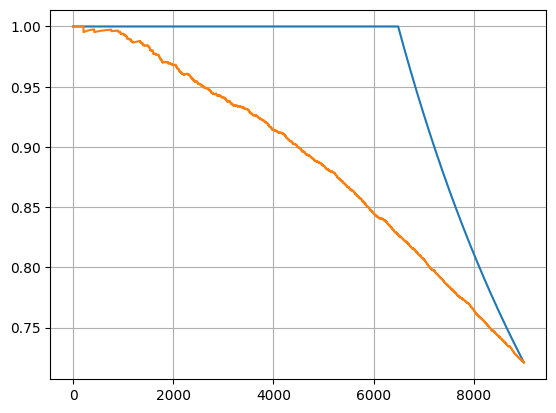

In [10]:
import matplotlib.pyplot as plt

res, r1, r2 = rAULC(np.array(distance),(np.array(results['pred']) == np.array(results['label'])))
plt.plot(range(len(r1)), r1)
plt.plot(range(len(r1)), r2)
plt.grid()
res

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
id = pd.DataFrame({
    'pred': results['pred'],
    'distances': results['distances'].cpu().numpy(),
    'entropy': results['entropy'].cpu().numpy()
})# 히스토그램과 KDE 그래프 그리기
plt.figure(figsize=(10, 6))
sns.kdeplot(data=id, x='distances', hue='predict',  palette='Set2', alpha=0.5, fill=True)
sns.kdeplot(data=id, x='entropy', hue='predict',  palette='Set2', alpha=0.5, fill=True)

plt.title(f'{method} in {model} with {data}', fontsize=16)
plt.xlabel('Uncertainty',  fontsize=14)
plt.ylabel('Probability Density',  fontsize=14)
plt.xticks(fontsize=12)  # x축 숫자 크기
plt.yticks(fontsize=12)  # y축 숫자 크기

plt.show()

AttributeError: 'list' object has no attribute 'cpu'

OOD[]

In [18]:
ood = pd.DataFrame({'pred': ood_results['pred'], 'label' : ood_results['label'], 'uncertaintiy':ood_d, 'type' : ood_results['type'], 'OOD' : ood_results['OOD']})
id = pd.DataFrame({'pred': results['pred'], 'label' :  np.array(results['label'], dtype=int),'uncertaintiy':distance, 'type' : results['type'], 'OOD' : results['OOD']})
#ood['u'] = 1/(ood['uncertaintiy'] + 1e-6) 
#id['u'] = 1/(id['uncertaintiy'] + 1e-6) 


ood_u = ood[ood.type == 'cifar100_ood']['uncertaintiy'].values.tolist() # ood['uncertaintiy'].values.tolist()  #ood[ood.type == 'cifar100_ood']['uncertaintiy'].values.tolist() #cifar100_ood, svhn_ood ood['uncertaintiy'] 
in_u = id['uncertaintiy'].values.tolist() 

auroc, aupr = get_auroc_aupr(in_u, ood_u)
print(f"{method}_AUROC: {auroc:.4f}")
print(f"{method}_AUPR: {aupr:.4f}")

my_AUROC: 0.6900
my_AUPR: 0.5405


In [15]:
ood_u = ood[ood.type == 'cifar100_ood']['uncertaintiy'].values.tolist() # ood['uncertaintiy'].values.tolist()  #ood[ood.type == 'cifar100_ood']['uncertaintiy'].values.tolist() #cifar100_ood, svhn_ood ood['uncertaintiy'] 
in_u = id['uncertaintiy'].values.tolist() 

auroc, aupr = get_auroc_aupr(in_u, ood_u)
print(f"{method}_AUROC: {auroc:.4f}")
print(f"{method}_AUPR: {aupr:.4f}")

my_AUROC: 0.6960
my_AUPR: 0.5487


In [16]:
results['uncertainty'] = np.array(results['uncertainty'])
ood_results['uncertainty'] = np.array(results['uncertainty'])

ijn = np.where(ood_results['uncertainty'] < 0.646, np.zeros_like(ood_results['uncertainty']), np.ones_like(ood_results['uncertainty']))
ood = np.where(results['uncertainty'] < 0.646, np.zeros_like(results['uncertainty']), np.ones_like(results['uncertainty']))
auroc, aupr = get_auroc_aupr(ijn, ood)
print(f"{method}_AUROC: {auroc:.4f}")
print(f"{method}_AUPR: {aupr:.4f}")

my_AUROC: 0.5000
my_AUPR: 0.7500


In [97]:
(ood_results['uncertainty'] < 0.01).sum()

5493

In [28]:
def find_best_threshold(in_uncertainty, out_uncertainty):
    # 모든 불확실성 값을 결합한 후 정렬하여 임계값 후보 생성
    combined_uncertainties = np.concatenate([in_uncertainty, out_uncertainty])
    thresholds = np.sort(combined_uncertainties)

    best_threshold = None
    best_auroc = 0.0

    # 각 threshold에 대해 AUROC를 계산하여 최적의 threshold를 찾음
    for threshold in thresholds:
        # Threshold 적용하여 예측 레이블 생성 (threshold 이상은 1, 미만은 0)
        in_predictions = (in_uncertainty >= threshold).astype(int)
        out_predictions = (out_uncertainty >= threshold).astype(int)

        # 예측 레이블 결합
        predictions = np.concatenate([in_predictions, out_predictions])
        labels = np.concatenate([np.zeros(len(in_uncertainty)), np.ones(len(out_uncertainty))])

        # AUROC 계산
        current_auroc = roc_auc_score(labels, predictions)

        # AUROC가 더 높은 경우 threshold를 업데이트
        if current_auroc > best_auroc:
            best_auroc = current_auroc
            best_threshold = threshold

    return best_threshold, best_auroc

find_best_threshold(in_u, ood_u)

(1.0, 0.5634166666666666)

In [75]:
mean = ood['uncertaintiy'].mean()
mean

0.038725656

In [74]:
for i in range(6):
    df = id[id.type == i]
    acc = round((df.pred == df.label).sum()/len(df),2) * 100
    mean = df['uncertaintiy'].mean()
    print(f"{i}_acc :", acc ," mean :", mean)

0_acc : 80.0  mean : 0.113121845
1_acc : 78.0  mean : 0.12234289
2_acc : 73.0  mean : 0.14420226
3_acc : 72.0  mean : 0.15627858
4_acc : 65.0  mean : 0.17529474
5_acc : 62.0  mean : 0.18650891


In [287]:
import torch

def accuracy(pred, target, topk=(1, 5)):
    """
    Computes the Top-k accuracy for the specified values of k.
    
    Args:
        pred (torch.Tensor): 모델의 예측 클래스 인덱스 (배치 크기)
        target (torch.Tensor): 실제 레이블 (배치 크기)
        topk (tuple): 정확도를 계산할 k 값들

    Returns:
        List of accuracies for each k in topk
    """
    batch_size = target.size(0)

    # 예측 결과와 실제 레이블 비교
    correct = pred.eq(target.view(-1))

    # 정확도 계산
    res = []
    for k in topk:
        # 배치 크기가 k보다 작을 수 있으므로 min 사용
        correct_k = correct[:min(k, batch_size)].float().sum(0, keepdim=True)
        res.append(correct_k.mul_(100.0 / batch_size))
    
    return res
  # 예측 값을 텐서로 변환



In [9]:
target = torch.tensor(id['pred'])  # 실제 레이블을 텐서로 변환
pred = torch.tensor(id['pred'])   
top1, top5 = accuracy(pred ,target, topk=(1, 5))
print(f'Top-1 Accuracy: {top1.item()}%')
print(f'Top-5 Accuracy: {top5.item()}%')

NameError: name 'accuracy' is not defined

In [290]:
id.sort_values(by = 'uncertaintiy',ascending= False)[:30]

,pred,label,uncertaintiy,type
4591,0,7,308.940643,tensor(3)
8875,9,8,303.639771,tensor(5)
8730,2,5,279.485931,tensor(5)
8091,2,9,264.495483,tensor(5)
4246,0,0,246.233582,tensor(2)
6925,4,0,237.698151,tensor(4)
6982,1,1,227.791550,tensor(4)
1265,6,5,221.463364,tensor(0)
2926,1,8,220.360641,tensor(1)
2199,1,1,220.044830,tensor(1)


In [241]:
id[id['type'] == 4]['uncertaintiy'].mean()

0.49153104

In [242]:
ood['uncertaintiy'].mean()

0.58620745

KeyboardInterrupt: 

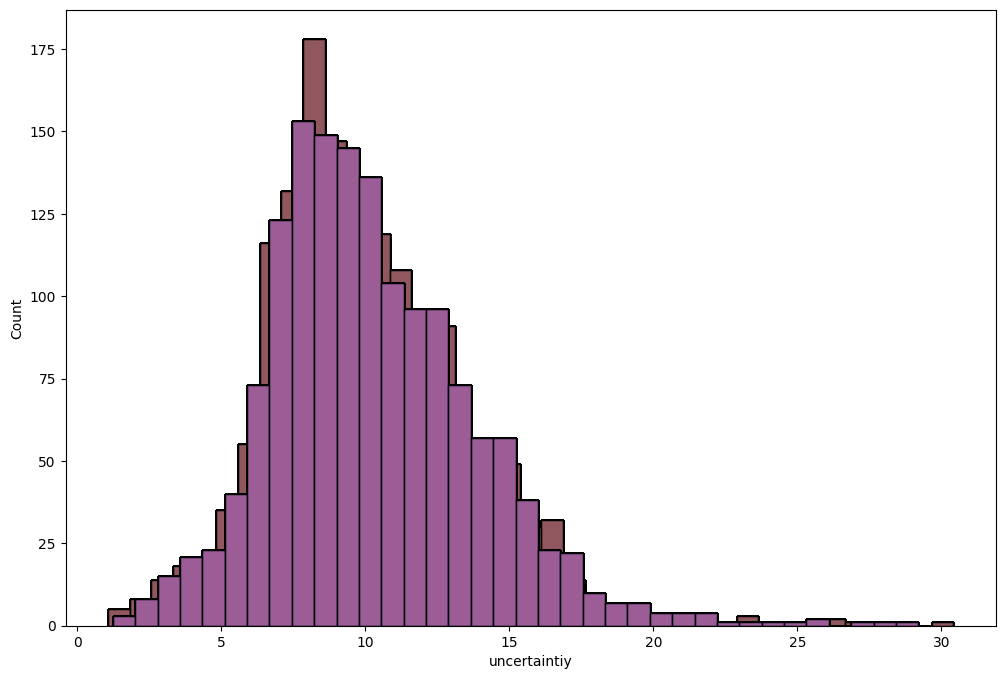

In [32]:



plt.figure(figsize=(12, 8))

# 범주별로 분포를 그리기
categories = id['type'].unique()
for category in categories:
    subset = id[id['type'] == category]['uncertaintiy']
    sns.histplot(subset)
plt.title('Distribution of b for each category in a')
plt.xlabel('Values of b')
plt.ylabel('Density')
plt.legend(title='Categories of a')
plt.show()


<Axes: xlabel='uncertaintiy', ylabel='Density'>

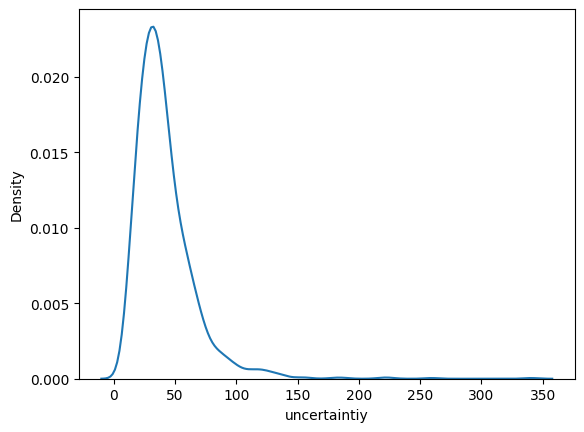

In [276]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
plt.figure()
subset = id[id.type == 1]['uncertaintiy']
sns.kdeplot(subset)

<Axes: xlabel='uncertaintiy', ylabel='Density'>

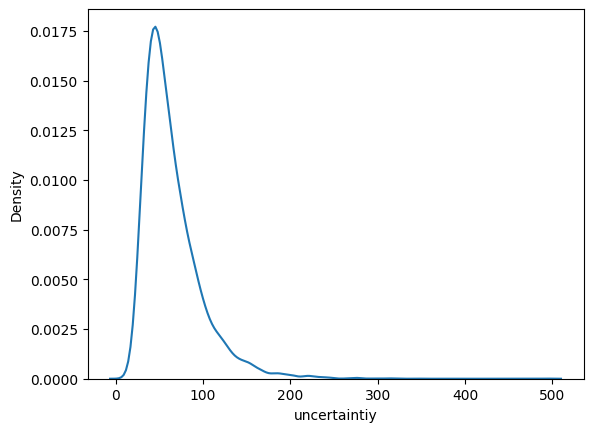

In [277]:
plt.figure()
subset = ood['uncertaintiy']
sns.kdeplot(subset)

In [ ]:
id[id['type'] == 5]['uncertaintiy'].mean()

8.223564

In [177]:
data = 'cifar10'
method ='vae.'
seed = 0
type = 'test'

current_dir = os.getcwd()

new_folder = f"result/{data}/{method}/seed_{seed}"
file = f"cifar10_test_{seed}.pkl"
ood_file = f"cifar10_ood_{seed}.pkl"
full_path = os.path.join(current_dir, new_folder,file)
ood_path = os.path.join(current_dir, new_folder,ood_file)

with open(full_path, 'rb') as f:
    results = pickle.load(f)
with open(ood_path, 'rb') as f:
    ood_results = pickle.load(f)

In [157]:
ood_results.keys()

dict_keys(['probs', 'preds', 'labels', 'distances1', 'distances2', 'ood_type', 'outputs', 'inference_times'])

In [159]:
len( ood_results['distances1'])

12000

In [158]:
ood = pd.DataFrame({'pred': ood_results['preds'], 'label' : ood_results['labels'], 'uncertaintiy':ood_results['distances1'], 'type' : ood_results['ood_type']})
id = pd.DataFrame({'pred': results['preds'], 'label' :  np.array(results['labels'], dtype=int),'uncertaintiy':results['distances1'], 'type' : results['severity_level']})
ood['u'] = 1/(ood['uncertaintiy'] + 1e-6) *100
id['u'] = 1/(id['uncertaintiy'] + 1e-6) * 100

ood_u = ood[ood.type == 'cifar100_ood']['u'].values.tolist() 
in_u = id['u'].values.tolist() 

auroc, aupr = get_auroc_aupr(in_u, ood_u)
print(f"{method}_AUROC: {auroc:.4f}")
print(f"{method}_AUPR: {aupr:.4f}")

vae._AUROC: 0.7012
vae._AUPR: 0.5684


In [53]:
a = id.pred == id.label
b = id['uncertaintiy']

In [55]:
n = a.shape[0]
np.argsort(b)

0       4786
1       1972
2       5044
3        125
4        938
        ... 
8995    1526
8996    8446
8997    4521
8998    5313
8999    5356
Name: uncertaintiy, Length: 9000, dtype: int64

In [57]:
a[np.argsort(b)]

4786     True
1972    False
5044     True
125      True
938      True
        ...  
1526    False
8446    False
4521     True
5313    False
5356    False
Length: 9000, dtype: bool

In [30]:
def aulc(labels, scores, reverse_sort: bool = False):
  n = labels.shape[0]

  if reverse_sort:
    sorted_idx = np.flip(np.argsort(scores), axis=0)
  else:
    sorted_idx = np.argsort(scores)
  sorted_labels = labels[sorted_idx]

  lift = np.zeros(n)
  lift[0] = sorted_labels[0] / np.mean(sorted_labels)
  _m = np.mean(sorted_labels)
  for i in range(1, n):
    lift[i] = (i * lift[i - 1] + sorted_labels[i] / _m) / (i + 1)

  step = 1 / n
  return lift, np.arange(step, 1 + step, step), np.sum(lift) * step - 1


def compute_raulc(labels, scores):
  y, x, area = aulc(labels, scores)
  y_opt, x_opt, area_opt = aulc(labels, labels, reverse_sort=True)

  return area / area_opt

In [51]:
compute_raulc(id.pred == id.label, id['uncertaintiy'])

1.0

In [3]:

class ECELoss(torch.nn.Module):
    def __init__(self, n_bins=15):
        """
        n_bins: ECE를 계산할 구간(bins)의 개수
        """
        super(ECELoss, self).__init__()
        self.n_bins = n_bins

    def forward(self, prob, labels):
        confidences, predictions = torch.max(prob, 1)
        accuracies = predictions.eq(labels)

        ece = torch.zeros(1, device=prob.device)
        bin_boundaries = torch.linspace(0, 1, self.n_bins + 1)

        for i in range(self.n_bins):
            bin_lower = bin_boundaries[i]
            bin_upper = bin_boundaries[i + 1]
            in_bin = confidences.gt(bin_lower) * confidences.le(bin_upper)
            prop_in_bin = in_bin.float().mean()

            if prop_in_bin.item() > 0:
                accuracy_in_bin = accuracies[in_bin].float().mean()
                avg_confidence_in_bin = confidences[in_bin].mean()
                ece += torch.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin

        return ece




In [4]:
import torch.nn as nn

nll_loss = nn.NLLLoss()

def calculate_nll(prob, labels):
    log_prob = F.log_softmax(prob)
    loss = nll_loss(log_prob, labels)
    return loss


In [5]:
current_dir = os.getcwd()
current_dir

'/home/nh/Coding/study'

In [19]:
criterion = nn.NLLLoss()

# 손실 계산


probs1 = F.softmax(torch.tensor(results['probs1']))
labels = torch.tensor(results['labels'])


ece_loss = ECELoss(n_bins=10)
ece1 = ece_loss(probs1, labels)

print(f"{method}_{seed}_ECE1: {ece1.item()}")

# NLL 계산
nll1 = calculate_nll(probs1, labels)
print(f"{method}_{seed}_NLL1: {nll1.item()}")


0927_0_ECE1: 0.20923255383968353
0927_0_NLL1: 1.7633570432662964


/tmp/ipykernel_13666/1618203962.py:6: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs1 = F.softmax(torch.tensor(results['probs1']))
/tmp/ipykernel_13666/2803181403.py:6: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  log_prob = F.log_softmax(prob)


In [20]:
criterion = nn.NLLLoss()

# 손실 계산


probs1 = F.softmax(torch.tensor(results['probs1']))
labels = torch.tensor(results['labels'])

probs2 = F.softmax(torch.tensor(results['probs2']))
labels = torch.tensor(results['labels'])

ece_loss = ECELoss(n_bins=10)
ece1 = ece_loss(probs1, labels)
ece2 = ece_loss(probs2, labels)

print(f"{method}_{seed}_ECE1: {ece1.item()}")
print(f"{method}_{seed}_ECE2: {ece2.item()}")

# NLL 계산
nll1 = calculate_nll(probs1, labels)
nll2 = calculate_nll(probs2, labels)
print(f"{method}_{seed}_NLL1: {nll1.item()}")
print(f"{method}_{seed}_NLL2: {nll2.item()}")

0927_0_ECE1: 0.20923255383968353
0927_0_ECE2: 0.281991183757782
0927_0_NLL1: 1.7633570432662964
0927_0_NLL2: 1.7589097023010254


/tmp/ipykernel_13666/3724201800.py:6: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs1 = F.softmax(torch.tensor(results['probs1']))
/tmp/ipykernel_13666/3724201800.py:9: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs2 = F.softmax(torch.tensor(results['probs2']))
/tmp/ipykernel_13666/2803181403.py:6: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  log_prob = F.log_softmax(prob)


In [23]:
probs = torch.tensor(results['probs'])
labels = torch.tensor(results['labels'])
# NLL 계산
nll = calculate_nll(probs, labels)
print(f"{method}_{seed}_NLL: {nll.item()}")

ece_loss = ECELoss(n_bins=10)
ece = ece_loss(probs, labels)
print(f"{method}_{seed}_ECE: {ece.item()}")


KeyError: 'probs'

In [10]:
ood_results.keys()

dict_keys(['probs1', 'probs2', 'preds1', 'preds2', 'uncertainties', 'labels', 'ood_type', 'entropies', 'inference_times'])

In [24]:
df = pd.DataFrame({'unc' :ood_results['uncertainties1'], 'type' : ood_results['ood_type']})
ood_unc1 = df[df.type == 'cifar100_ood']['unc'].values.tolist() 
in_unc1 = results['uncertainties1']


In [25]:
df = pd.DataFrame({'unc' :ood_results['uncertainties2'], 'type' : ood_results['ood_type']})
ood_unc2 = df[df.type == 'cifar100_ood']['unc'].values.tolist() 
in_unc2 = results['uncertainties2']


In [28]:
ood_unc1 = np.array(ood_unc1)
in_unc1 = np.array(in_unc1)
ood_unc2 = np.array(ood_unc2)
in_unc2 = np.array(in_unc2)
# 배열 간 뺄셈 수행



ood_unc = ood_unc2 - ood_unc1
in_unc = in_unc2 - in_unc1

In [113]:

auroc, aupr = get_auroc_aupr(in_unc, ood_unc)
print(f"{method}_AUROC: {auroc:.4f}")
print(f"{method}_AUPR: {aupr:.4f}")

NameError: name 'ood_unc' is not defined

In [21]:
import numpy as np

def compute_ece(probs, labels, n_bins=10):
    # probs: 모델이 예측한 각 클래스의 확률 (shape: [num_samples, num_classes])
    # labels: 실제 클래스 레이블 (shape: [num_samples])
    # n_bins: ECE를 계산하기 위한 빈의 개수
    
    bin_boundaries = np.linspace(0, 1, n_bins + 1)  # [0, 0.1, 0.2, ..., 1.0] 형태
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]

    confidences = np.max(probs, axis=1)  # 각 예측의 최대 확률 (confidence)
    predictions = np.argmax(probs, axis=1)  # 예측된 클래스

    ece = 0.0  # ECE 값을 저장할 변수
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        # 현재 빈에 속한 샘플 찾기
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        prop_in_bin = np.mean(in_bin)  # 해당 빈에 속한 샘플의 비율

        if prop_in_bin > 0:  # 해당 빈에 샘플이 있을 경우에만 계산
            # 빈 내에서의 평균 confidence와 정확도
            avg_confidence_in_bin = np.mean(confidences[in_bin])
            accuracy_in_bin = np.mean(predictions[in_bin] == labels[in_bin])

            # ECE 계산 (빈의 크기에 비례해서 weighted sum)
            ece += prop_in_bin * np.abs(avg_confidence_in_bin - accuracy_in_bin)

    return ece
import torch.nn.functional as F

def compute_nll(probs, labels):
    # probs: 모델이 예측한 각 클래스의 확률 (shape: [num_samples, num_classes])
    # labels: 실제 클래스 레이블 (shape: [num_samples])

    # 실제 정답 레이블에 해당하는 예측 확률만 선택
    num_samples = labels.shape[0]
    predicted_probs = probs[np.arange(num_samples), labels]

    # NLL 계산 (로그 확률의 음수)
    nll = -np.mean(np.log(predicted_probs))
    
    return nll


In [288]:
data = 'cifar10'
method ='ensemble'
seed = 0 #128 #0
type = 'test'

current_dir = os.getcwd()

new_folder = f"result/{data}/{method}/seed_{seed}"
file = f"cifar10_test_{seed}.pkl"
ood_file = f"cifar10_ood_{seed}.pkl"
full_path = os.path.join(current_dir, new_folder,file)
ood_path = os.path.join(current_dir, new_folder,ood_file)

with open(full_path, 'rb') as f:
    results = pickle.load(f)
with open(ood_path, 'rb') as f:
    ood_results = pickle.load(f)

In [289]:
print(results.keys())
print(ood_results.keys())

dict_keys(['output', 'prob', 'pred', 'uncertaintiy', 'label', 'type', 'inference_times', 'acc'])
dict_keys(['output', 'prob', 'pred', 'uncertaintiy', 'label', 'type', 'inference_times'])


In [290]:
results['acc']

0.7592222222222222

In [291]:
df = pd.DataFrame({'uncertaintiy' :ood_results['uncertaintiy'], 'type' : ood_results['type']})
in_df = pd.DataFrame({'uncertaintiy' :results['uncertaintiy'], 'type' : results['type']})
ood_unc1 = df[df.type == 'cifar100_ood']['uncertaintiy'].values.tolist() 
in_unc1 = in_df['uncertaintiy'].values.tolist() 
auroc, aupr = get_auroc_aupr(in_unc1, ood_unc1)
print(f"{method}_AUROC: {auroc:.4f}")
print(f"{method}_AUPR: {aupr:.4f}")

ensemble_AUROC: 0.5145
ensemble_AUPR: 0.3778


In [292]:
data = 'cifar10'
method ='vae.'
seed = 3423 #0
type = 'test'

current_dir = os.getcwd()

new_folder = f"result/{data}/{method}/seed_{seed}"
file = f"cifar10_test_{seed}.pkl"
ood_file = f"cifar10_ood_{seed}.pkl"
full_path = os.path.join(current_dir, new_folder,file)
ood_path = os.path.join(current_dir, new_folder,ood_file)

with open(full_path, 'rb') as f:
    results = pickle.load(f)
with open(ood_path, 'rb') as f:
    ood_results = pickle.load(f)

In [273]:

probs1 = torch.tensor(np.array(results['probs']))
labels = torch.tensor(results['labels'])
logit = torch.tensor(results['outputs'])

ece_loss = ECELoss(n_bins=10)
ece1 = ece_loss(probs1, labels)

print(f"{method}_{seed}_ECE1: {ece1.item()}")

# NLL 계산
nll1 = calculate_nll(logit, labels)
print(f"{method}_{seed}_NLL1: {nll1.item()}")

vae._3423_ECE1: 0.2094832807779312
vae._3423_NLL1: 2.288726806640625


/tmp/ipykernel_264173/2803181403.py:6: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  log_prob = F.log_softmax(prob)


In [279]:
print(results.keys())
print(ood_results.keys())

dict_keys(['outputs', 'probs', 'preds', 'labels', 'severity_level', 'distances1', 'distances2', 'inference_times', 'acc'])
dict_keys(['probs', 'preds', 'labels', 'distances1', 'distances2', 'ood_type', 'outputs', 'inference_times'])


In [280]:
results['inference_times']

0.7357935905456543

In [274]:
in_df = pd.DataFrame({'distances' :results['distances1'],'distances2' :results['distances2'], 'type' : results['severity_level']})
in_df

,distances,distances2,type
0,13.411082,0.011568,tensor(0)
1,9.337379,0.016645,tensor(0)
2,23.181105,0.023243,tensor(0)
3,23.187517,0.015135,tensor(0)
4,12.641193,0.014251,tensor(0)
...,...,...,...
8995,14.566754,0.012257,tensor(5)
8996,14.239614,0.011726,tensor(5)
8997,11.928464,0.015645,tensor(5)
8998,9.106527,0.017218,tensor(5)


In [275]:
df = pd.DataFrame({'distances' :results['distances1'], 'type' : results['severity_level']})
df[df.type == 5]['distances'].mean()

11.954851

In [276]:
df = pd.DataFrame({'distances' :ood_results['distances1'], 'type' : ood_results['ood_type']})
df[df.type == 'cifar100_ood']['distances'].mean()

10.1436405

In [277]:
in_df = pd.DataFrame({'distances' :results['distances1'],'distances2' :results['distances2'], 'type' : results['severity_level']})
in_df['u'] = 1  / (in_df['distances'] + 0.0001) *100
in_df

,distances,distances2,type,u
0,13.411082,0.011568,tensor(0),7.456464
1,9.337379,0.016645,tensor(0),10.709529
2,23.181105,0.023243,tensor(0),4.313840
3,23.187517,0.015135,tensor(0),4.312647
4,12.641193,0.014251,tensor(0),7.910583
...,...,...,...,...
8995,14.566754,0.012257,tensor(5),6.864900
8996,14.239614,0.011726,tensor(5),7.022613
8997,11.928464,0.015645,tensor(5),8.383239
8998,9.106527,0.017218,tensor(5),10.981013


In [266]:
df = pd.DataFrame({'distances' :ood_results['distances1'],'distances2' :ood_results['distances2'], 'type' : ood_results['ood_type']})
df['u']= df['distances2'] / (df['distances'] + 0.0001) 
in_df = pd.DataFrame({'distances' :results['distances1'],'distances2' :results['distances2'], 'type' : results['severity_level']})
in_df['u'] = in_df['distances2']  / (in_df['distances'] + 0.0001) 
ood_unc1 = df[df.type == 'cifar100_ood']['u'].values.tolist() 
in_unc1 = in_df['u'].values.tolist() 
auroc, aupr = get_auroc_aupr(in_unc1, ood_unc1)
print(f"{method}_AUROC: {auroc:.4f}")
print(f"{method}_AUPR: {aupr:.4f}")

vae._AUROC: 0.6517
vae._AUPR: 0.4963


In [278]:
df = pd.DataFrame({'distances' :ood_results['distances1'],'distances2' :ood_results['distances2'], 'type' : ood_results['ood_type']})
df['u']= 1 / (df['distances'] + 0.0001) *100
in_df = pd.DataFrame({'distances' :results['distances1'],'distances2' :results['distances2'], 'type' : results['severity_level']})
in_df['u'] = 1 / (in_df['distances'] + 0.0001) *100
ood_unc1 = df[df.type == 'cifar100_ood']['u'].values.tolist() 
in_unc1 = in_df['u'].values.tolist() 
auroc, aupr = get_auroc_aupr(in_unc1, ood_unc1)
print(f"{method}_AUROC: {auroc:.4f}")
print(f"{method}_AUPR: {aupr:.4f}")

vae._AUROC: 0.7234
vae._AUPR: 0.5862


In [268]:
df = pd.DataFrame({'distances' :ood_results['distances1'], 'type' : ood_results['ood_type']},)
ood_unc1 = df[df.type == 'cifar100_ood']['distances'].values.tolist() 
in_unc1 = results['distances1'] 
auroc, aupr = get_auroc_aupr(in_unc1, ood_unc1)
print(f"{method}_AUROC: {auroc:.4f}")
print(f"{method}_AUPR: {aupr:.4f}")

vae._AUROC: 0.2950
vae._AUPR: 0.2865


In [269]:
df = pd.DataFrame({'distances' :results['distances1'], 'type' : results['severity_level'] , 'preds' :results['preds'] , 'labels' :results['labels']})
df['u'] = 1 / (df['distances'] + 0.0001) * 100
df[df.preds != df.labels]['u']

6       12.504838
9        6.991624
14       7.505252
20       5.710257
25      13.879207
          ...    
8979    14.447922
8981    15.997065
8982    11.379002
8989     8.918637
8994     8.432462
Name: u, Length: 2585, dtype: float32

In [271]:
df_sorted = df.sort_values(by='u', ascending = False)
df_sorted[:30]

,distances,type,preds,labels,u
1831,120.633629,tensor(1),8,8,0.828956
5514,115.308090,tensor(3),8,8,0.867241
1129,113.276917,tensor(0),8,8,0.882792
29,109.964500,tensor(0),8,8,0.909384
1849,104.421753,tensor(1),8,8,0.957654
2761,104.258469,tensor(1),8,8,0.959154
1237,101.599701,tensor(0),8,8,0.984254
6303,96.206764,tensor(4),8,8,1.039427
2556,93.667694,tensor(1),8,8,1.067603
2721,92.538155,tensor(1),8,8,1.080634


In [ ]:
df = pd.DataFrame({'distances' :ood_results['distances1'],'distances2' :ood_results['distances2'], 'type' : ood_results['ood_type']})
df['u']= df['distances2'] / (df['distances'] + 0.0001) 
in_df = pd.DataFrame({'distances' :results['distances1'],'distances2' :results['distances2'], 'type' : results['severity_level']})
in_df['u'] = in_df['distances2']  / (in_df['distances'] + 0.0001) 
ood_unc1 = df[df.type == 'cifar100_ood']['u'].values.tolist() 
in_unc1 = in_df['u'].values.tolist() 
auroc, aupr = get_auroc_aupr(in_unc1, ood_unc1)
print(f"{method}_AUROC: {auroc:.4f}")
print(f"{method}_AUPR: {aupr:.4f}")

vae_AUROC: 0.3522
vae_AUPR: 0.3057
